In [23]:
import pandas as pd
import geopandas as gpd

In [24]:
basins_eu_me = gpd.read_file("../data/hybas_eu_lev01-06_v1c/hybas_eu_lev04_v1c.shp")
rivers_eu = gpd.read_file("../data/HydroRIVERS_v10_eu_shp/HydroRIVERS_v10_eu.shp")

In [38]:
mask_strahler_five = rivers_eu["ORD_STRA"] >= 5
rivers_eu_five = rivers_eu[mask_strahler_five]

<Axes: >

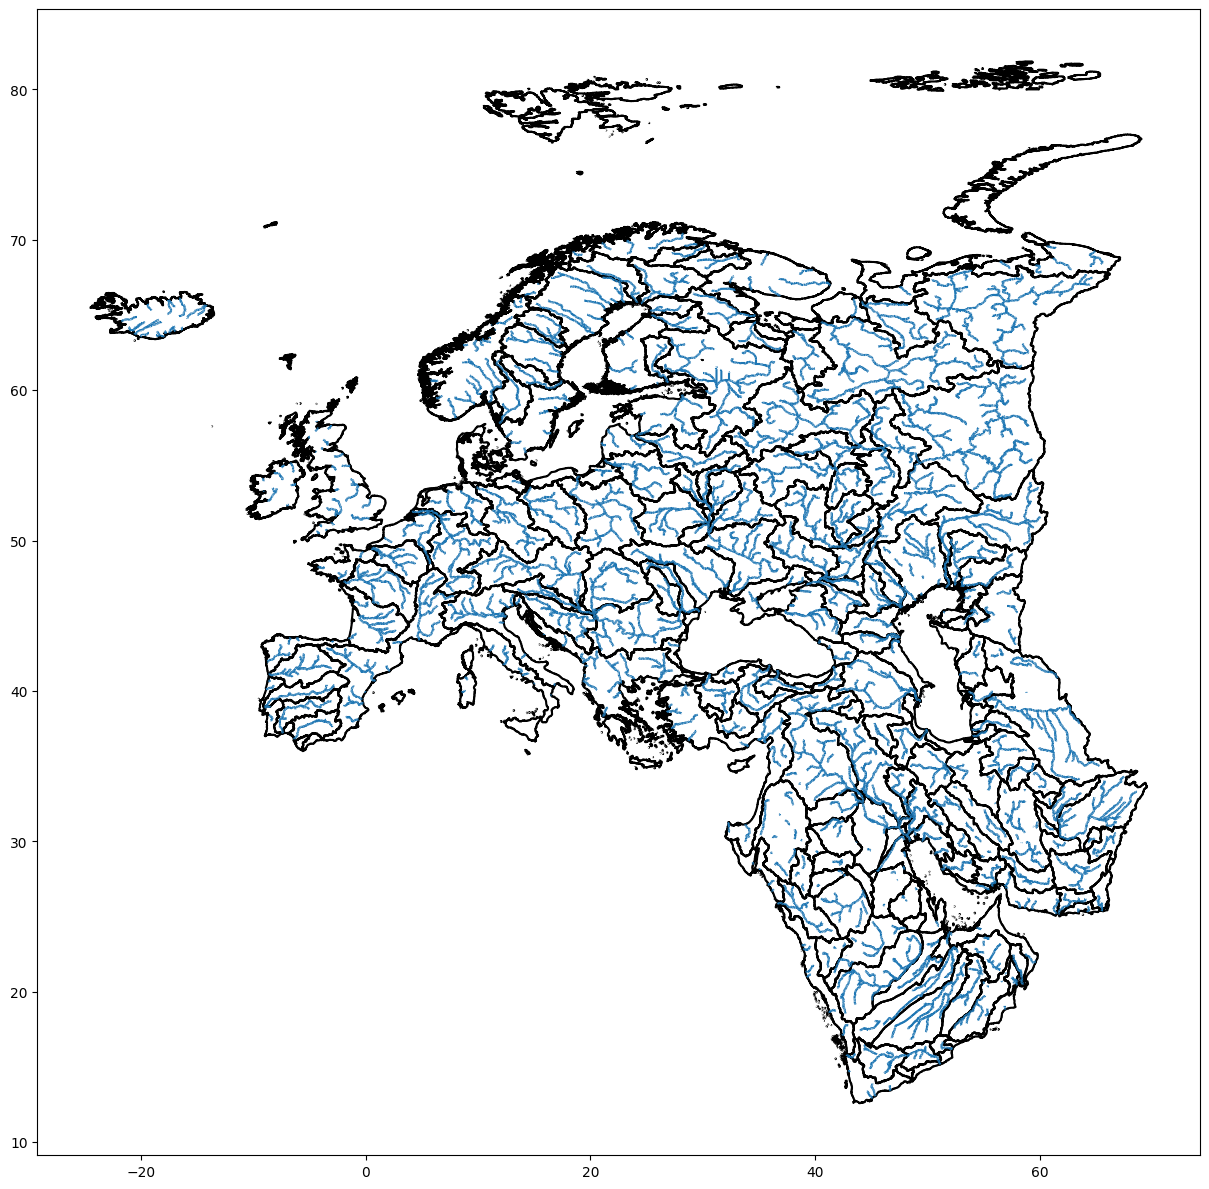

In [53]:
ax = basins_eu_me.boundary.plot(edgecolor = "k", figsize= (15, 15))
rivers_eu_five.plot(ax = ax)

In [49]:
IPB = basins_eu_me.iloc[45:53]
iberian = basins_eu_me[44:54]

In [50]:
rivers_in_IPB = gpd.sjoin(rivers_eu, IPB, predicate='intersects', how='inner')

<Axes: >

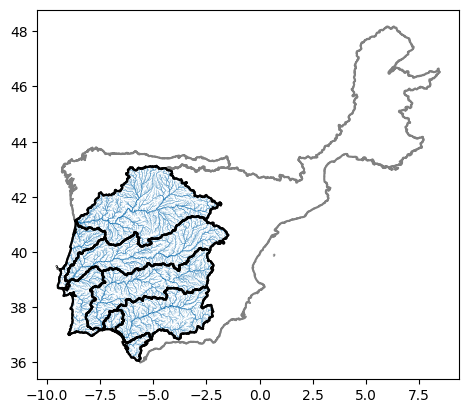

In [57]:
sizes = rivers_in_IPB["ORD_STRA"].fillna(1).astype(float) * 0.1
ax = IPB.boundary.plot(edgecolor = "k", zorder = 10)
iberian.boundary.plot(edgecolor = "grey", ax = ax, zorder = 1)
rivers_in_IPB.plot(ax = ax,linewidth=sizes)